<a href="https://colab.research.google.com/github/febriansyahadin/PCVK_Ganjil_2025/blob/main/Week6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### TUGAS PRAKTIKUM

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


2. 2. Import beberapa library berikut yang akan digunakan selama uji coba praktikum
minggu ke-6 berikut.

In [2]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob


3. Buatlah histogram citra seperti output histogram berikut berdasarkan flowchart di bawah ini : (Gunakan gambar lena.jpg)

Text(0.5, 0, 'Intensitas Warna')

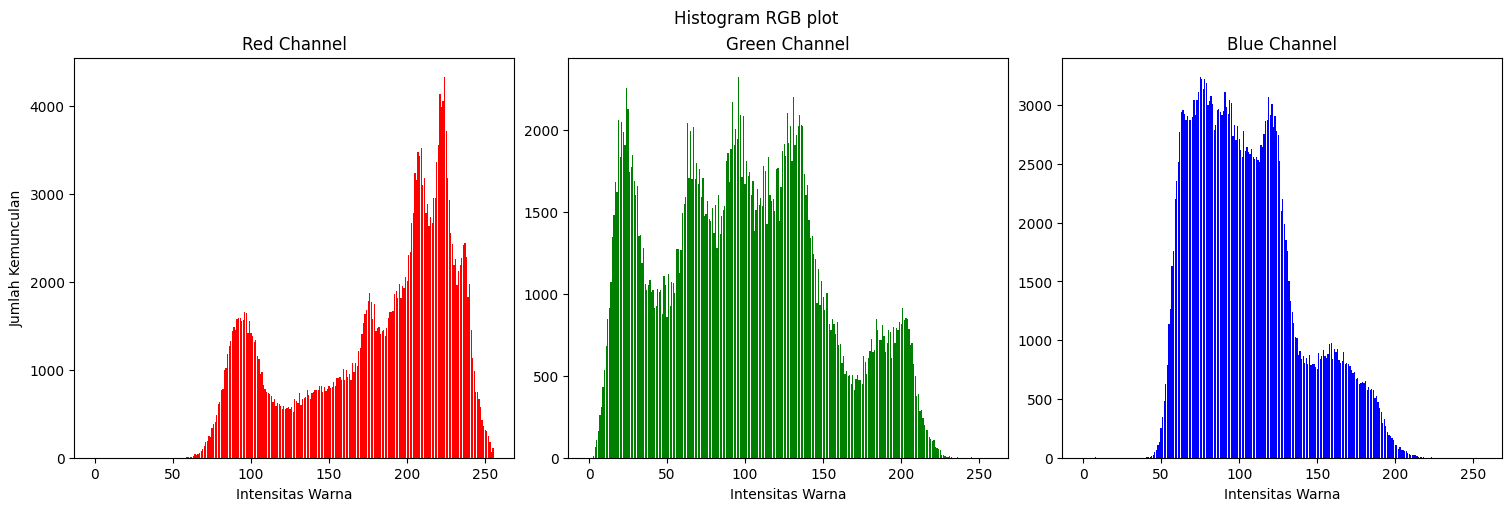

In [3]:
img = cv.imread('/content/drive/MyDrive/PCVK/Image/Lenna.png')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)  # ubah BGR ke RGB

# Pisahkan channel R, G, B
R, G, B = img[:,:,0], img[:,:,1], img[:,:,2]

# Hitung histogram manual untuk tiap channel
hist_r = np.zeros(256, dtype=int)
hist_g = np.zeros(256, dtype=int)
hist_b = np.zeros(256, dtype=int)

for y in range(img.shape[0]):
    for x in range(img.shape[1]):
        hist_r[R[y,x]] += 1
        hist_g[G[y,x]] += 1
        hist_b[B[y,x]] += 1

# Tampilkan histogram RGB
plt.figure(figsize=(15,5), constrained_layout=True)
plt.suptitle("Histogram RGB plot")

plt.subplot(1,3,1)
plt.bar(np.arange(256), hist_r, color='red')
plt.title("Red Channel")
plt.xlabel("Intensitas Warna")
plt.ylabel("Jumlah Kemunculan")
# plt.ylim(0, 2500) # Set y-axis limit

plt.subplot(1,3,2)
plt.bar(np.arange(256), hist_g, color='green')
plt.title("Green Channel")
plt.xlabel("Intensitas Warna")
# plt.ylim(0, 2500) # Set y-axis limit

plt.subplot(1,3,3)
plt.bar(np.arange(256), hist_b, color='blue')
plt.title("Blue Channel")
plt.xlabel("Intensitas Warna")
# plt.ylim(0, 2500) # Set y-axis limit

4. Setelah mengerjakan soal no. 3, buatlah histogram citra yang sama akan tetapi menggunakan library yang dimiliki oleh NumPy yaitu “histogram”. Bandingkan hasilnya. Apakah output muncul sama?

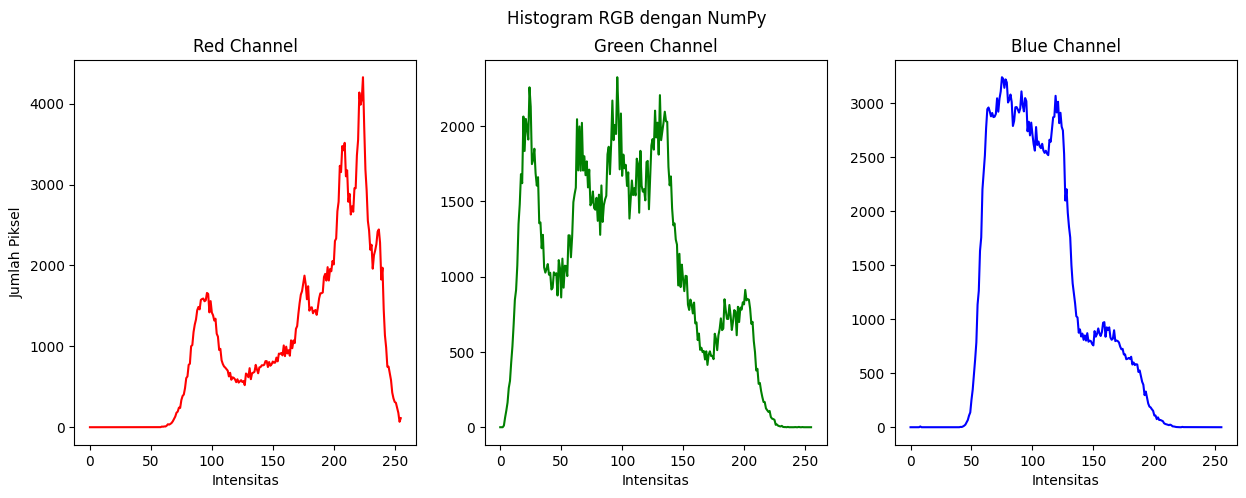

In [5]:
# Baca gambar berwarna
img = cv.imread('//content/drive/MyDrive/PCVK/Image/Lenna.png')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Pisahkan channel R, G, B
R, G, B = img[:,:,0], img[:,:,1], img[:,:,2]

# Hitung histogram dengan NumPy
hist_r, bins_r = np.histogram(R, bins=256, range=(0,256))
hist_g, bins_g = np.histogram(G, bins=256, range=(0,256))
hist_b, bins_b = np.histogram(B, bins=256, range=(0,256))

# Tampilkan hasil histogram
plt.figure(figsize=(15,5))
plt.suptitle("Histogram RGB dengan NumPy")

plt.subplot(1,3,1)
plt.plot(hist_r, color='red')
plt.title("Red Channel")
plt.xlabel("Intensitas")
plt.ylabel("Jumlah Piksel")

plt.subplot(1,3,2)
plt.plot(hist_g, color='green')
plt.title("Green Channel")
plt.xlabel("Intensitas")

plt.subplot(1,3,3)
plt.plot(hist_b, color='blue')
plt.title("Blue Channel")
plt.xlabel("Intensitas")

plt.show()


5. Buatlah histogram citra seperti output histogram equalization dan juga tampilan gambar sebelum dan sesudah proses histogram equalization berikut berdasarkan flowchart di bawah ini : (Gunakan gambar lena_lc.jpg)

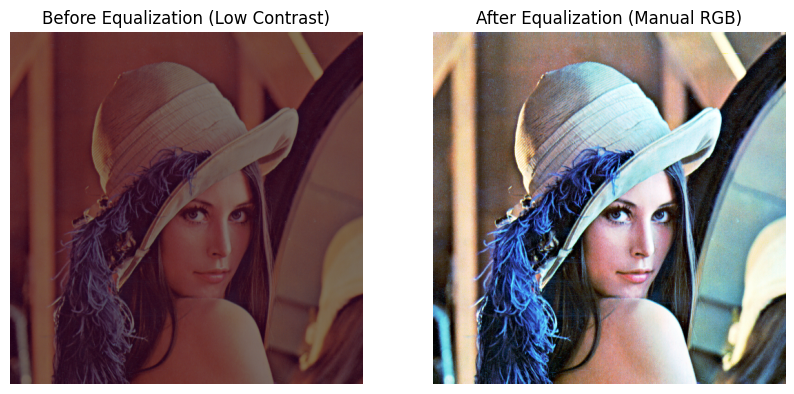

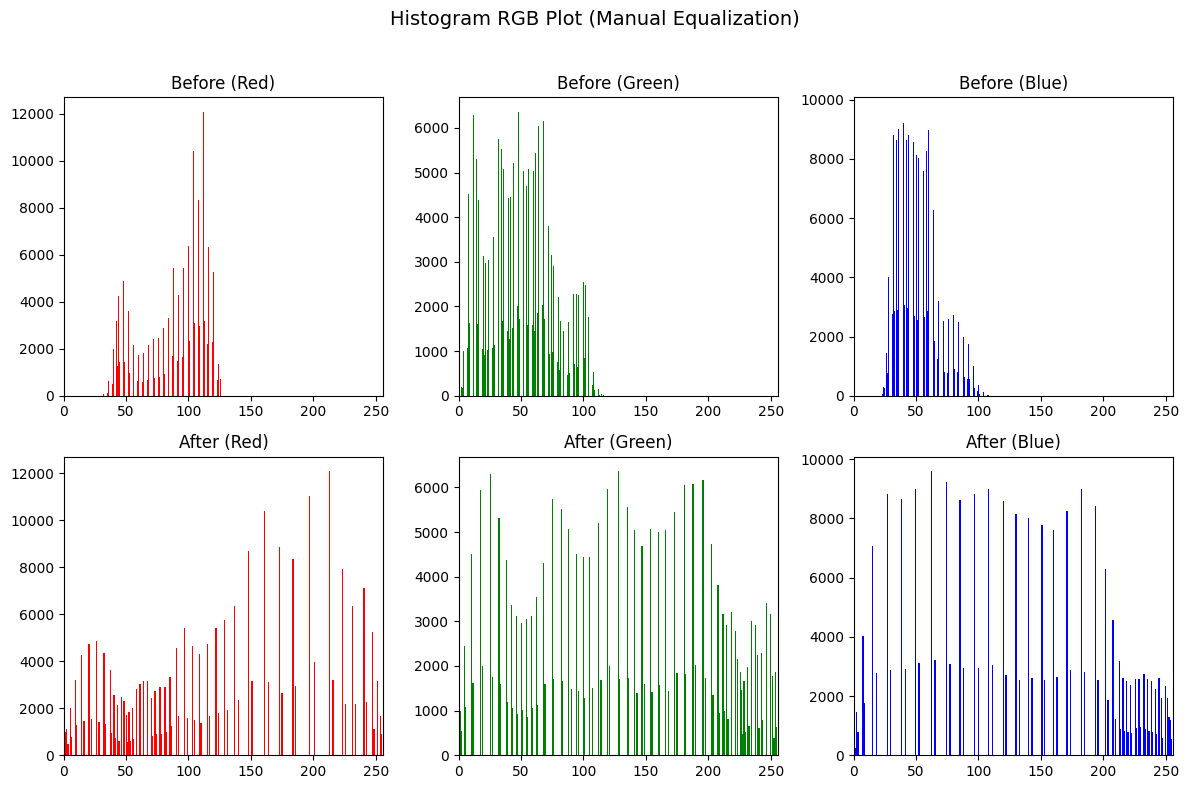

In [6]:
# Baca gambar berwarna
img = cv.imread('/content/drive/MyDrive/PCVK/Image/Lenna.png')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

def manual_hist_equalization_rgb(img_rgb):
    # Pisah channel R, G, B
    r, g, b = cv.split(img_rgb)

    def equalize_channel_manual(channel):
        # Hitung histogram (256 level)
        hist, _ = np.histogram(channel.flatten(), bins=256, range=[0,256])
        cdf = hist.cumsum()                       # cumulative distribution
        cdf_normalized = cdf / cdf[-1]            # normalisasi ke [0,1]
        mapping = np.round(cdf_normalized * 255)  # mapping ke [0–255]
        eq_channel = mapping[channel]             # ubah setiap pixel
        return eq_channel.astype(np.uint8), hist, cdf

    # Equalize tiap channel manual
    r_eq, r_hist, r_cdf = equalize_channel_manual(r)
    g_eq, g_hist, g_cdf = equalize_channel_manual(g)
    b_eq, b_hist, b_cdf = equalize_channel_manual(b)

    # Gabungkan channel kembali
    img_eq = cv.merge((r_eq, g_eq, b_eq))
    return img_eq, (r, g, b, r_eq, g_eq, b_eq, r_hist, g_hist, b_hist)

# Buat citra low contrast
lena_lc = cv.convertScaleAbs(img, alpha=0.5, beta=0)
equalized_rgb_manual, (r, g, b, r_eq, g_eq, b_eq, r_hist, g_hist, b_hist) = manual_hist_equalization_rgb(lena_lc)

# --- Tampilkan gambar before & after ---
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(lena_lc)
plt.title("Before Equalization (Low Contrast)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(equalized_rgb_manual)
plt.title("After Equalization (Manual RGB)")
plt.axis("off")
plt.show()

# --- Plot Histogram RGB ---
colors = ['r', 'g', 'b']
titles = ['Red', 'Green', 'Blue']

plt.figure(figsize=(12,8))
plt.suptitle("Histogram RGB Plot (Manual Equalization)", fontsize=14)

for i, (orig, eq, color, title) in enumerate(zip([r,g,b],[r_eq,g_eq,b_eq], colors, titles)):
    plt.subplot(2,3,i+1)
    plt.hist(orig.flatten(), bins=256, color=color)
    plt.title(f"Before ({title})")
    plt.xlim([0,256])

    plt.subplot(2,3,i+4)
    plt.hist(eq.flatten(), bins=256, color=color)
    plt.title(f"After ({title})")
    plt.xlim([0,256])

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()


6. Setelah mengerjakan soal no. 5, buatlah histogram citra yang sama akan tetapi menggunakan library yang dimiliki oleh CV2 yaitu “equalizeHist”. Bandingkan hasilnya. Apakah output muncul sama?


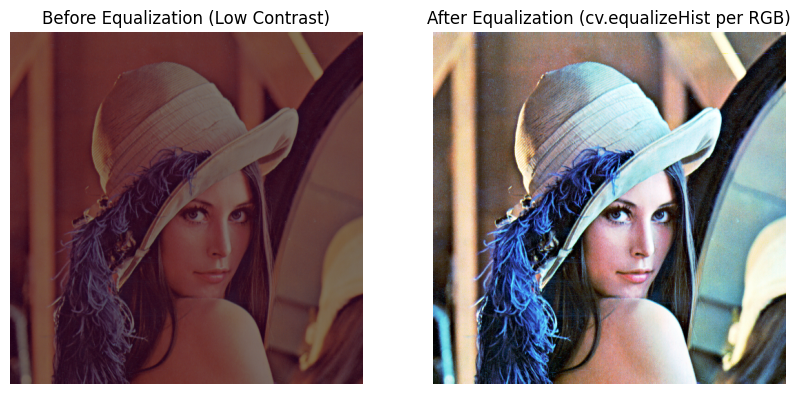

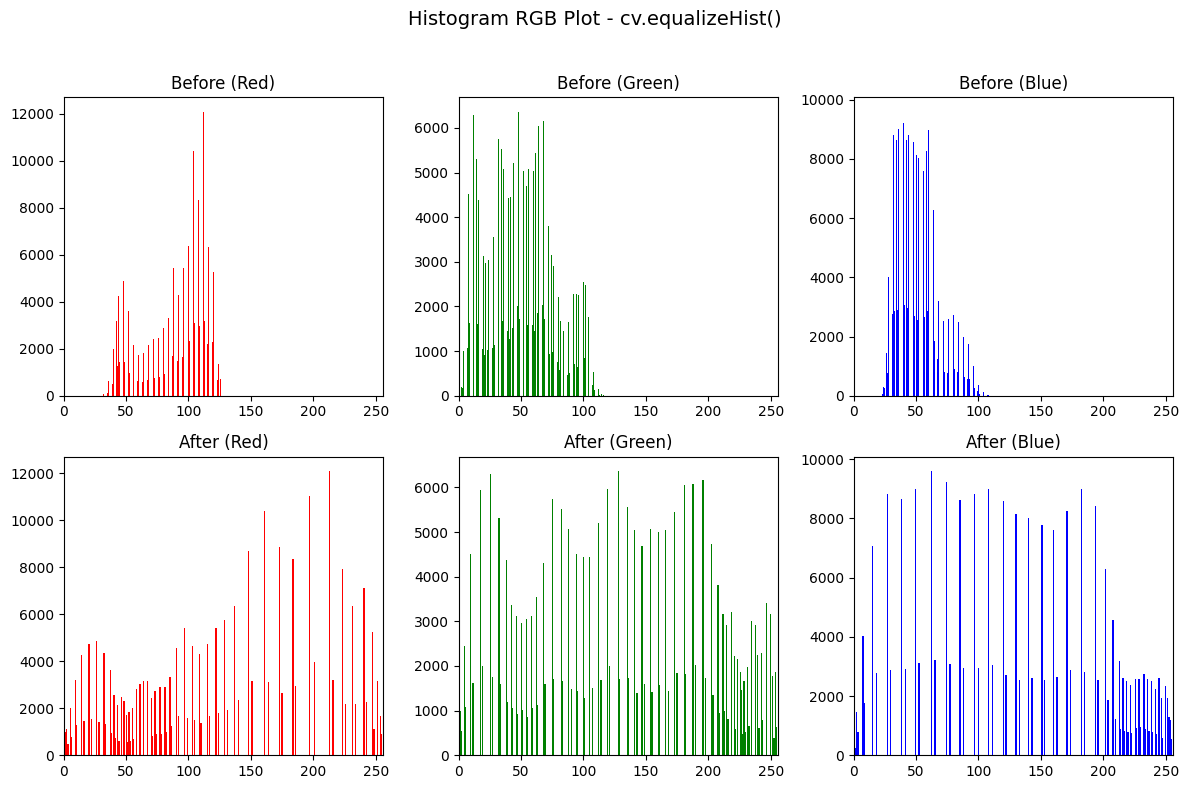

In [7]:
# Baca gambar berwarna
img = cv.imread('/content/drive/MyDrive/PCVK/Image/Lenna.png')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

def equalize_hist_cv2_rgb(img_rgb):
    r, g, b = cv.split(img_rgb)
    r_eq = cv.equalizeHist(r)
    g_eq = cv.equalizeHist(g)
    b_eq = cv.equalizeHist(b)
    img_eq = cv.merge((r_eq, g_eq, b_eq))
    return img_eq, (r, g, b, r_eq, g_eq, b_eq)

# Gunakan gambar low contrast sama seperti sebelumnya
lena_lc = cv.convertScaleAbs(img, alpha=0.5, beta=0)
equalized_cv_rgb, (r, g, b, r_eq, g_eq, b_eq) = equalize_hist_cv2_rgb(lena_lc)

# --- Tampilkan hasil before & after ---
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(lena_lc)
plt.title("Before Equalization (Low Contrast)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(equalized_cv_rgb)
plt.title("After Equalization (cv.equalizeHist per RGB)")
plt.axis("off")
plt.show()

# --- Plot Histogram RGB ---
colors = ['r','g','b']
titles = ['Red','Green','Blue']

plt.figure(figsize=(12,8))
plt.suptitle("Histogram RGB Plot - cv.equalizeHist()", fontsize=14)

for i, (orig, eq, color, title) in enumerate(zip([r,g,b],[r_eq,g_eq,b_eq],colors,titles)):
    plt.subplot(2,3,i+1)
    plt.hist(orig.flatten(), bins=256, color=color)
    plt.title(f"Before ({title})")
    plt.xlim([0,256])
    plt.subplot(2,3,i+4)
    plt.hist(eq.flatten(), bins=256, color=color)
    plt.title(f"After ({title})")
    plt.xlim([0,256])

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

Berdasarkan hasil pengamatan saya, bentuk histogram hasil equalization secara manual dan menggunakan cv2.equalizeHist() menunjukkan pola yang hampir sama, yaitu distribusi intensitas piksel yang lebih merata dibanding citra asli. Namun, keduanya tidak identik karena fungsi cv2.equalizeHist() menggunakan metode perhitungan CDF dan normalisasi yang lebih presisi secara internal. Secara visual, hasil cv2.equalizeHist() tampak sedikit lebih halus dan natural dibandingkan dengan hasil manual.

7. Lakukanlah proses pemetaan 16 juta warna RGB ke dalam 8 warna saja, yaitu hitam, hijau, kuning, biru, cyan, magenta, putih seperti output berikut berdasarkan flowchart di bawah ini! (Gunakan gambar lena.jpg)


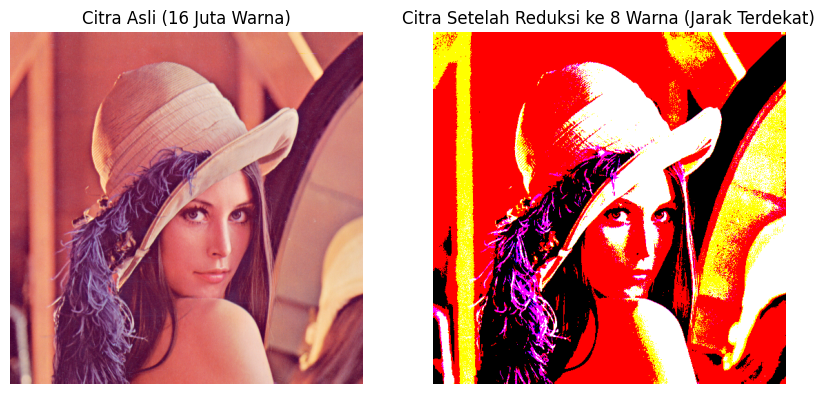

In [8]:
# Baca gambar berwarna
img = cv.imread('/content/drive/MyDrive/PCVK/Image/Lenna.png')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)


# 8 warna dasar (RGB)
palette = np.array([
    [0, 0, 0],        # Hitam
    [0, 255, 0],      # Hijau
    [255, 255, 0],    # Kuning
    [0, 0, 255],      # Biru
    [0, 255, 255],    # Cyan
    [255, 0, 255],    # Magenta
    [255, 0, 0],      # Merah
    [255, 255, 255]   # Putih
], dtype=np.uint8)

def quantize_8color_by_distance(image, palette):
    # Ubah gambar jadi daftar pixel (N x 3)
    pixels = image.reshape((-1, 3)).astype(np.float32)

    # Hitung jarak Euclidean ke setiap warna dasar (8 warna)
    distances = np.linalg.norm(pixels[:, np.newaxis] - palette[np.newaxis, :], axis=2)

    # Cari indeks warna terdekat
    nearest = np.argmin(distances, axis=1)

    # Ganti pixel dengan warna terdekat
    new_pixels = palette[nearest]

    # Kembalikan ke bentuk semula
    return new_pixels.reshape(image.shape).astype(np.uint8)

# Proses reduksi warna
reduced_img = quantize_8color_by_distance(img, palette)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Citra Asli (16 Juta Warna)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(reduced_img)
plt.title("Citra Setelah Reduksi ke 8 Warna (Jarak Terdekat)")
plt.axis("off")
plt.show()



8. 8. Lakukanlah proses dithering Floyd and Steinberg seperti output berikut (tampilan image awal, dan tampilan setelah dithering) berdasarkan flowchart di bagian bawah halaman modul ini! (Gunakan gambar lena.jpg)

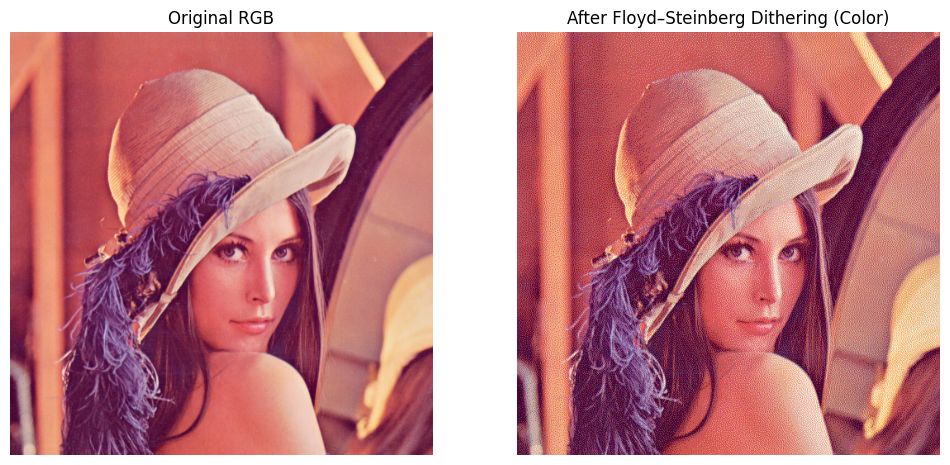

In [9]:
# Baca gambar berwarna
img = cv.imread('/content/drive/MyDrive/PCVK/Image/Lenna.png')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Copy untuk dithering
dithered = img_rgb.astype(float)
h, w, c = dithered.shape

# Tentukan jumlah level warna (semakin besar, semakin halus)
levels = 4  # bisa coba 4, 6, 8, dst
step = 255 / (levels - 1)

for y in range(h-1):
    for x in range(1, w-1):
        for ch in range(3):  # 3 channel: R, G, B
            old_pixel = dithered[y, x, ch]
            new_pixel = round(old_pixel / step) * step  # kuantisasi multi-level
            dithered[y, x, ch] = new_pixel
            error = old_pixel - new_pixel

            # Sebarkan error
            dithered[y, x+1, ch]     += error * 7/16
            dithered[y+1, x-1, ch]   += error * 3/16
            dithered[y+1, x, ch]     += error * 5/16
            dithered[y+1, x+1, ch]   += error * 1/16

# Pastikan nilai pixel valid
dithered = np.clip(dithered, 0, 255).astype(np.uint8)

# Tampilkan hasil
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title("Original RGB")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(dithered)
plt.title("After Floyd–Steinberg Dithering (Color)")
plt.axis("off")
plt.show()


9. Menggunakan lena_lc.jpg rubah menjadi grey image, kemudian terapkan histogram equalization sehingga terjadi perbaikan sebaran warna pada citra. Setelah itu dari hasil histogram equalization implementasikan proses dithering Floyd and Steinberg sehingga menampilkan gambar di bawah ini!

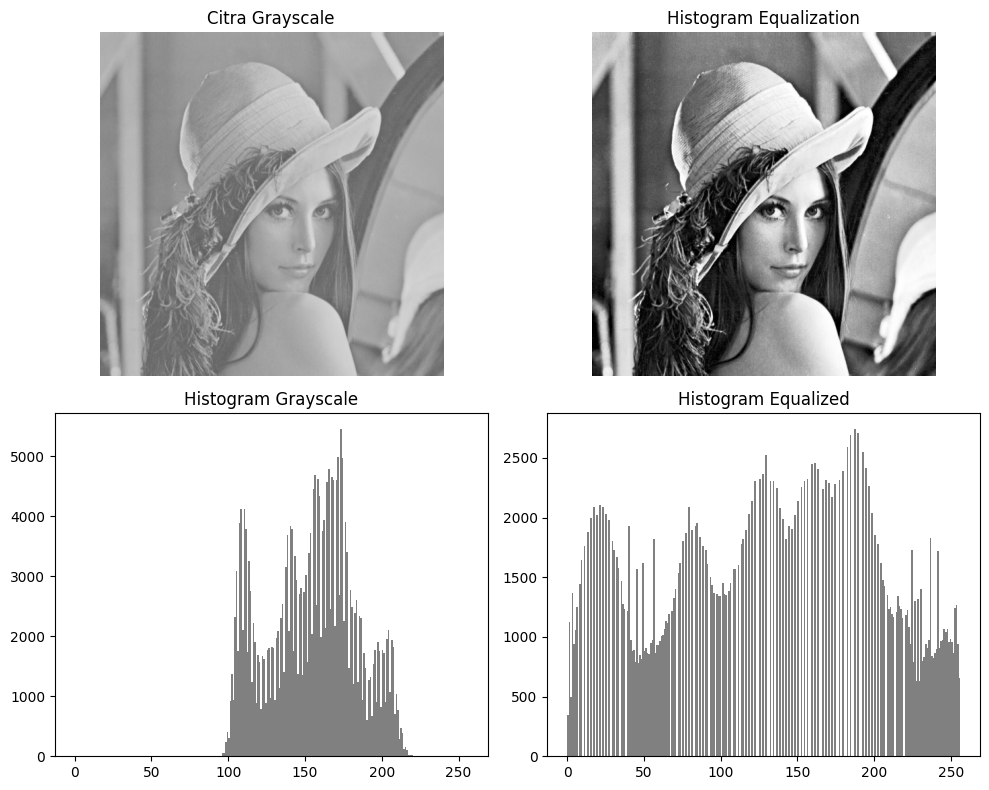

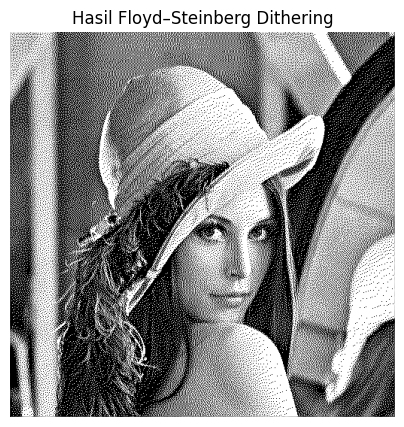

In [10]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Baca gambar berwarna
img = cv.imread('/content/drive/MyDrive/PCVK/Image/Lenna.png')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Convert to grayscale
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

gray_closed = gray.astype(np.float32)
gray_closed = gray_closed * 0.6 + 80   # 0.6 => menurunkan kontras, +80 => memberi tone abu-abu

gray_closed = np.clip(gray_closed, 0, 255).astype(np.uint8)

# 3. Histogram Equalization
equalized = cv.equalizeHist(gray)

# 4. Tampilkan hasil
plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.imshow(gray_closed, cmap='gray', vmin=0, vmax=255)
plt.title('Citra Grayscale')
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(equalized, cmap='gray', vmin=0, vmax=255)
plt.title('Histogram Equalization')
plt.axis('off')

plt.subplot(2,2,3)
plt.hist(gray_closed.ravel(), bins=256, range=[0,256], color='gray')
plt.title('Histogram Grayscale')

plt.subplot(2,2,4)
plt.hist(equalized.ravel(), bins=256, range=[0,256], color='gray')
plt.title('Histogram Equalized')

plt.tight_layout()
plt.show()


# === 4. Floyd–Steinberg Dithering ===
def floyd_steinberg_dithering(img):
    img = img.astype(float)
    h, w = img.shape
    for y in range(h - 1):
        for x in range(1, w - 1):
            old_pixel = img[y, x]
            new_pixel = 255 if old_pixel >= 128 else 0
            img[y, x] = new_pixel
            error = old_pixel - new_pixel

            img[y, x + 1] += error * 7 / 16
            img[y + 1, x - 1] += error * 3 / 16
            img[y + 1, x] += error * 5 / 16
            img[y + 1, x + 1] += error * 1 / 16

    return np.clip(img, 0, 255).astype(np.uint8)

# Terapkan dithering ke hasil equalized
dithered = floyd_steinberg_dithering(equalized)

# === 5. Tampilkan hasil dithering ===
plt.figure(figsize=(5,5))
plt.imshow(dithered, cmap='gray')
plt.title('Hasil Floyd–Steinberg Dithering')
plt.axis('off')
plt.show()